In [88]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [89]:
df = pd.read_excel("premiums_rest.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [90]:
df["Genetical_Risk"] = 0

In [91]:
df.shape

(29904, 14)

In [92]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [93]:
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0


<h2 align="center" style="color:blue">Exploratory Data Analysis & Data Cleaning</h2>

#### Handling null and duplicated values

In [94]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [95]:
df["smoking_status"].unique()

array(['No Smoking', 'Regular', 'Occasional', nan, 'Does Not Smoke',
       'Not Smoking', 'Smoking=0'], dtype=object)

In [96]:
df["income_level"].dtype

dtype('O')

In [97]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
df[["smoking_status"]] = imputer.fit_transform(df[["smoking_status"]])

In [98]:
df["smoking_status"].unique()

array(['No Smoking', 'Regular', 'Occasional', 'Does Not Smoke',
       'Not Smoking', 'Smoking=0'], dtype=object)

In [99]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
df[["income_level"]] = imputer.fit_transform(df[["income_level"]])

In [100]:
df["income_level"].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29904.000000,29904.000000,29904.000000,29904.000000,29904.0
mean,43.396536,2.380116,23.362059,20893.036684,0.0
std,13.411893,1.431140,24.737076,6935.844219,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15698.000000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


In [103]:
df[df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-1, -3])

In [104]:
df["number_of_dependants"] = abs(df["number_of_dependants"])

In [105]:
df["number_of_dependants"].describe()

count    29904.000000
mean         2.386136
std          1.421082
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

#### Handling outliers

#### 1. Numerical columns

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29904 entries, 0 to 29903
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    29904 non-null  int64 
 1   gender                 29904 non-null  object
 2   region                 29904 non-null  object
 3   marital_status         29904 non-null  object
 4   number_of_dependants   29904 non-null  int64 
 5   bmi_category           29904 non-null  object
 6   smoking_status         29904 non-null  object
 7   employment_status      29903 non-null  object
 8   income_level           29904 non-null  object
 9   income_lakhs           29904 non-null  int64 
 10  medical_history        29904 non-null  object
 11  insurance_plan         29904 non-null  object
 12  annual_premium_amount  29904 non-null  int64 
 13  genetical_risk         29904 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 3.2+ MB


In [107]:
numerical_columns = df.select_dtypes(["int64"]).columns
numerical_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

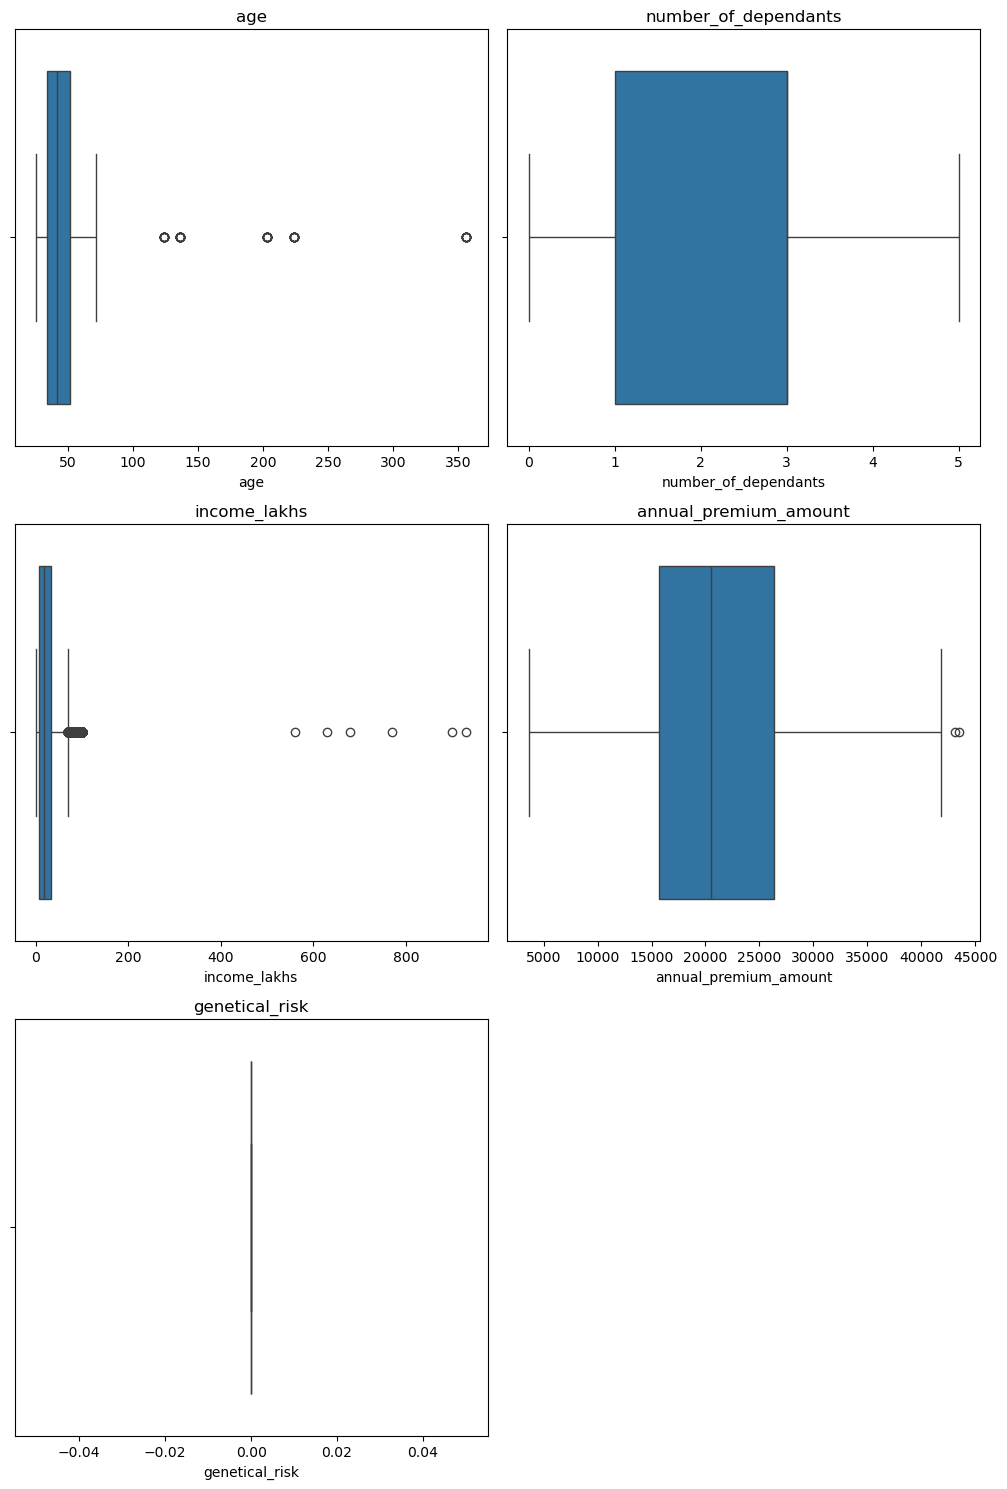

In [108]:
num_plots = len(numerical_columns)
num_cols = 2  
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col) 

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

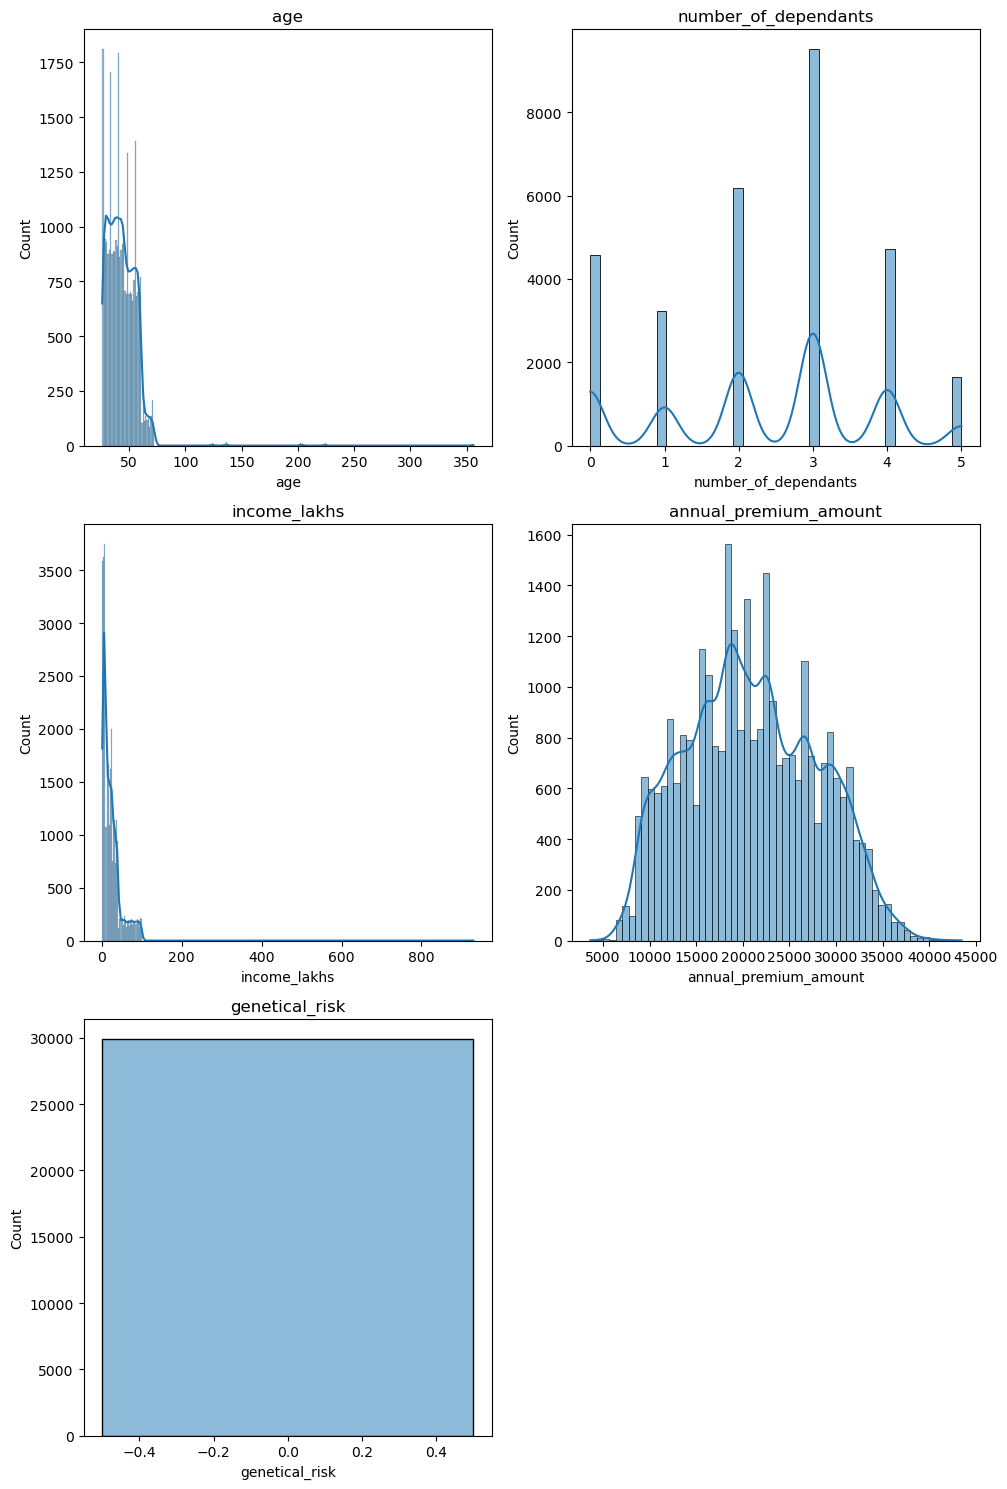

In [109]:
num_plots = len(numerical_columns)
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col) 

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [110]:
df[df["age"]>100].shape

(58, 14)

In [111]:
df[df["age"]>100]["age"].unique()

array([224, 124, 136, 203, 356])

In [112]:
df1 = df[df["age"]<100]
df1["age"].describe()

count    29846.000000
mean        43.095993
std         11.042658
min         26.000000
25%         34.000000
50%         42.000000
75%         52.000000
max         72.000000
Name: age, dtype: float64

In [113]:
Q1 = df1["income_lakhs"].quantile(0.25)
Q3 = df1["income_lakhs"].quantile(0.75)
IQR = Q3-Q1
upper_range = Q3 + 1.5*IQR
lower_range = Q1 - 1.5*IQR
print(upper_range, lower_range)

69.5 -30.5


67 lakhs is a normal income in india, so we will drop the records where the values exceed the range of 0.999 quantile

In [114]:
df1[df1["income_lakhs"]> upper_range].shape

(2090, 14)

In [115]:
df1[df1["income_lakhs"]> upper_range]["income_lakhs"].unique()

array([ 77,  83,  84,  71,  97,  92,  93,  78,  86,  95,  85,  81,  79,
        80,  89,  82, 100,  70,  88,  75,  94,  90,  74,  91,  99,  87,
        96,  98,  73,  72, 560,  76, 630, 900, 930, 770, 680])

In [116]:
threshold_quantile = df1["income_lakhs"].quantile(0.999)
threshold_quantile

np.float64(100.0)

In [117]:
df1[df1["income_lakhs"]>threshold_quantile]["income_lakhs"].shape

(6,)

In [118]:
df2 = df1[df1["income_lakhs"] <= threshold_quantile]
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0


In [119]:
df2.shape

(29840, 14)

<Axes: xlabel='income_lakhs', ylabel='Count'>

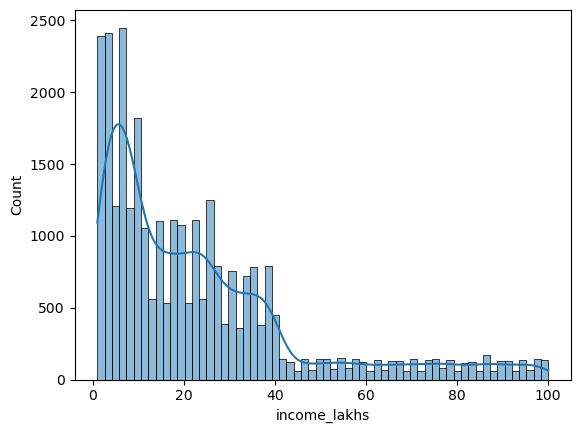

In [120]:
sns.histplot(data = df2, x ="income_lakhs", kde = True)

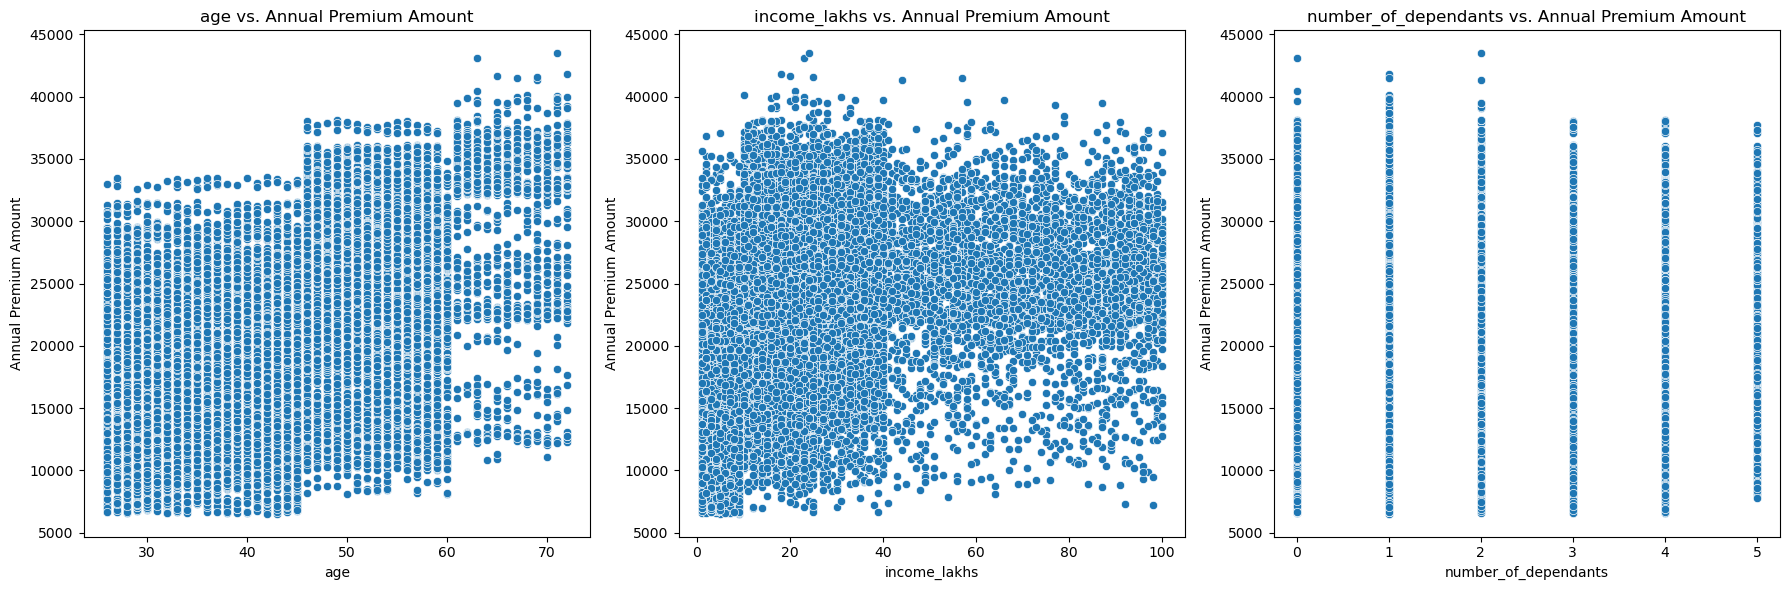

In [121]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6)) 

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout() 
plt.show()

#### 2.Categorical column

In [122]:
Categorical_columns = df2.select_dtypes(["object"]).columns
Categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [123]:
for col in Categorical_columns:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer' nan]
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


In [124]:
df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
}, inplace=True)

df2['smoking_status'].unique()

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_23916\263445883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['smoking_status'].replace({
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_23916\263445883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['smoking_status'].replace({


array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [125]:
df2["smoking_status"].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L          799  3554    4355
25L - 40L          301  2636    3142
<10L              6054   527    4351
> 40L              214  3288     619


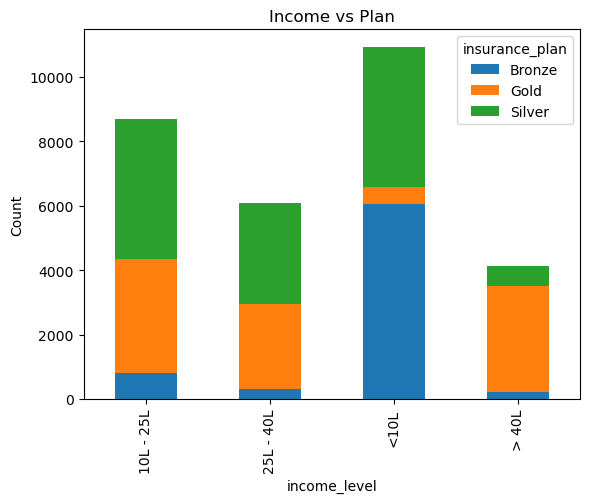

In [126]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

Most of the people which less than 10 lakh income have bronze tier of insurance plan

<h2 align="center" style="color:blue">Feature Engineering</h2>

In [127]:
df2.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0


In [128]:
df2["medical_history"].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

##### Assigning some score to each disease based on domain understanding

In [129]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

In [130]:
df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_23916\2811996713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_23916\2811996713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_2391

In [131]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,none
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,none


### calculating risk scores

In [132]:
df2['total_risk_score'] = 0
for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

max_score = df2['total_risk_score'].max()
min_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.head(2)

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_23916\3931687836.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['total_risk_score'] = 0
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_23916\3931687836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['total_risk_score'] += df2[disease].map(risk_scores)
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_23916\3931687836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,none,6,0.428571


In [133]:
df3 = df2.drop(["medical_history", "disease1", "disease2", "total_risk_score"], axis=1)
df3.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,9053,0,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,16339,0,0.428571


#### Label Encoding for ordinal columns

In [134]:
df3['insurance_plan'] = df3['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [135]:
df3["income_level"].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [136]:
df3['income_level'] = df3['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})
df3.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score
2122,48,Female,Southeast,Married,3,Obesity,No Smoking,Self-Employed,2,22,3,30573,0,0.428571
4906,42,Female,Southeast,Unmarried,1,Normal,No Smoking,Salaried,1,2,3,22388,0,0.357143
13537,46,Female,Northwest,Married,4,Normal,No Smoking,Salaried,1,2,2,18182,0,0.357143
2465,57,Female,Southwest,Married,4,Obesity,No Smoking,Salaried,1,8,2,22846,0,0.428571
2669,43,Female,Southwest,Unmarried,0,Normal,Occasional,Salaried,2,11,1,10340,0,0.357143


In [137]:
cat_columns2 = df3.select_dtypes(["object"]).columns
cat_columns2

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status'],
      dtype='object')

In [138]:
for col in cat_columns2:
    print(f"{col} : {df3[col].unique()}")

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer' nan]


#### one hot encoding for nominal columns

In [139]:
df4 = pd.get_dummies(df3, columns=cat_columns2, drop_first=True, dtype=int)
df4.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1


In [140]:
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'genetical_risk',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [141]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29840 entries, 0 to 29903
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              29840 non-null  int64  
 1   number_of_dependants             29840 non-null  int64  
 2   income_level                     29840 non-null  int64  
 3   income_lakhs                     29840 non-null  int64  
 4   insurance_plan                   29840 non-null  int64  
 5   annual_premium_amount            29840 non-null  int64  
 6   genetical_risk                   29840 non-null  int64  
 7   normalized_risk_score            29840 non-null  float64
 8   gender_Male                      29840 non-null  int64  
 9   region_Northwest                 29840 non-null  int64  
 10  region_Southeast                 29840 non-null  int64  
 11  region_Southwest                 29840 non-null  int64  
 12  marital_status_Unmarrie

### Calculating VIF to measure multicollinearity

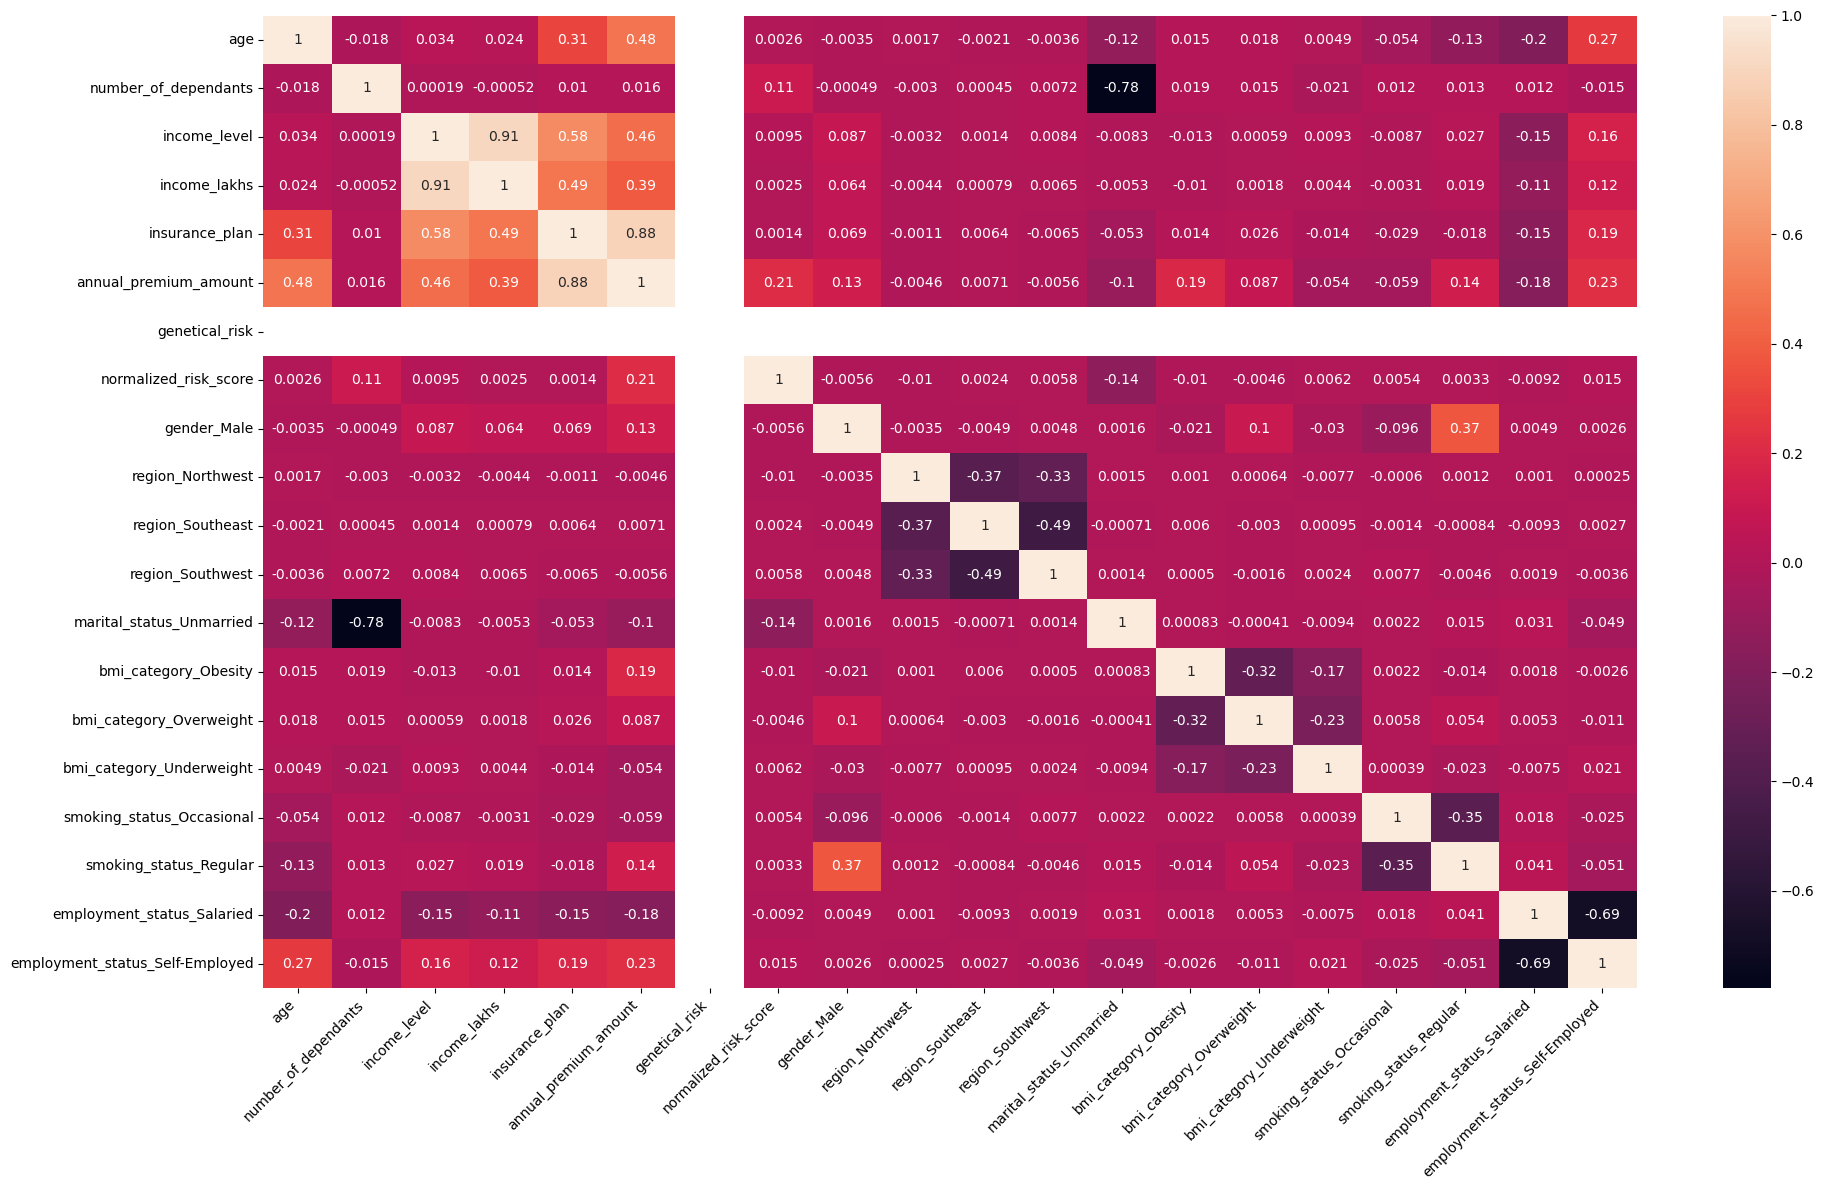

In [142]:
cm = df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### scaling columns using min max scalar

In [143]:
df4.sample(6)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
1784,52,2,4,92,2,22181,0,0.571429,1,0,1,0,0,0,0,0,0,0,0,1
13696,30,1,1,1,1,12376,0,0.428571,1,1,0,0,1,0,1,0,1,0,0,1
4613,31,2,3,32,2,18274,0,0.428571,1,0,1,0,0,0,0,0,0,1,0,1
22136,35,0,2,14,2,19789,0,1.000000,0,0,0,1,1,0,0,1,0,0,0,1
24964,41,1,4,72,3,21674,0,0.000000,0,0,0,1,1,0,0,1,1,0,0,1
13170,41,3,3,29,2,17713,0,0.000000,1,0,1,0,0,1,0,0,0,0,0,1


In [144]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan', 'genetical_risk']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.0,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000,29840.000000
mean,0.371642,0.477587,0.371191,0.224488,0.544186,0.0,0.426398,0.549095,0.200603,0.352614,0.302111,0.253318,0.196816,0.294940,0.110221,0.173190,0.374531,0.466086,0.354256
std,0.240067,0.284118,0.351129,0.226800,0.378951,0.0,0.240106,0.497592,0.400458,0.477792,0.459181,0.434919,0.397599,0.456023,0.313170,0.378418,0.484010,0.498857,0.478295
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.0,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.0,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.0,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [145]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [146]:
calculate_vif(X)

C:\Users\Sarthak\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.921142
1,number_of_dependants,6.276727
2,income_level,13.887094
3,income_lakhs,11.185632
4,insurance_plan,5.272000
5,genetical_risk,NaN
6,normalized_risk_score,3.811497
7,gender_Male,2.598494
8,region_Northwest,2.123307
9,region_Southeast,2.979715


##### dropping columns one by one

In [147]:
calculate_vif(X.drop('income_level', axis="columns"))

C:\Users\Sarthak\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.862576
1,number_of_dependants,6.275976
2,income_lakhs,2.678049
3,insurance_plan,4.575779
4,genetical_risk,NaN
5,normalized_risk_score,3.809181
6,gender_Male,2.590841
7,region_Northwest,2.122615
8,region_Southeast,2.978784
9,region_Southwest,2.709048


In [148]:
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:blue">Model Training</h2>

#### Attempt 1:
using linear regression, ridge regression, xgboost

### Linear Regression

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (20888, 18)
x test:  (8952, 18)
y train:  (20888,)
y test:  (8952,)


In [150]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9535039037392332, 0.953588277508763)

In [151]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr, "R2_score: ", r2_lr)

Linear Regression ==> MSE:  2214853.8412195295 RMSE:  1488.2385028010563 R2_score:  0.953588277508763


In [152]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([ 7000.192925, -1336.951078,  -780.73504 , 14855.720815,
          -0.      ,  6049.459685,    57.443613,   -42.628565,
         -12.410281,    -7.966785,  -689.73303 ,  3927.945761,
        1968.426049,   584.700409,   852.65939 ,  2800.222411,
         -90.610519,   241.176056])

In [153]:
feature_importance = model_lr.coef_

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])
coef_df

,Coefficients
age,7.000193e+03
number_of_dependants,-1.336951e+03
income_lakhs,-7.807350e+02
insurance_plan,1.485572e+04
genetical_risk,-2.273737e-13
normalized_risk_score,6.049460e+03
gender_Male,5.744361e+01
region_Northwest,-4.262857e+01
region_Southeast,-1.241028e+01
region_Southwest,-7.966785e+00


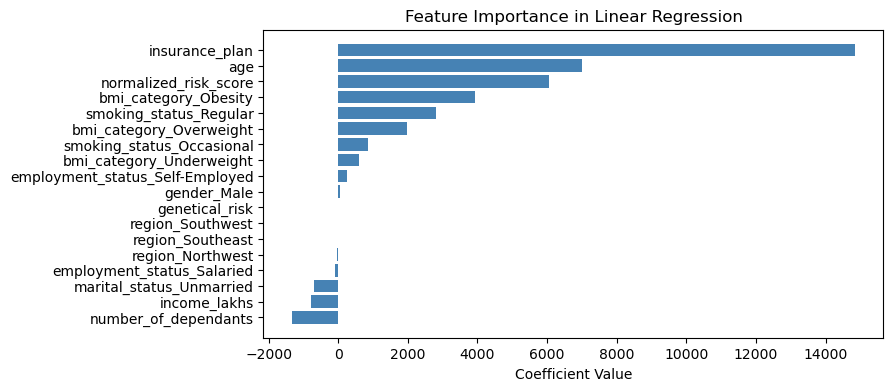

In [154]:
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)


plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

### Ridge Regression 

In [155]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.9535037346807764, 0.9535905776578315)

In [156]:
y_pred = model_rg.predict(X_test)

mse_rl = mean_squared_error(y_test, y_pred)
r2_rl = r2_score(y_test, y_pred)
rmse_rl = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_rl, "RMSE: ", rmse_rl, "r2_score: ", r2_rl)

Ridge Regression ==> MSE:  2214744.073821843 RMSE:  1488.2385028010563 r2_score:  0.9535905776578315


### XG Boost

In [157]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9944465756416321

In [158]:
y_pred = model_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_xgb, "RMSE: ", rmse_xgb)

XGBoost Regression ==> MSE:  265019.875 RMSE:  1488.2385028010563


### Attempt 2:
1. using XG boost
2. using cross validation
3. Parameter tuning using optuna
4. Using early stopping for computational resources

In [159]:
import optuna


class EarlyStoppingCallback:
    def __init__(self, patience=4, min_trials=10):
        self.patience = patience      
        self.min_trials = min_trials  

    def __call__(self, study, trial):
        if trial.number + 1 < self.min_trials:
            return
        trials_since_best = trial.number - study.best_trial.number
        if trials_since_best >= self.patience:
            print(f"Early stopping at trial {trial.number}: no improvement in "
                  f"{self.patience} trials after best trial {study.best_trial.number}.")
            study.stop()

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state": 42,
    }
    model = XGBRegressor(**params, max_iter=10000)
    scores = cross_val_score(model, X_train, y_train, cv=3,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -scores.mean()  

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(
    objective,
    n_trials=50,                                             
    callbacks=[EarlyStoppingCallback(patience=4, min_trials=10)],
)

# ---- Best result ----
print("Best trial number:", study_xgb.best_trial.number)
print("Best CV RMSE:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)

best_model_XGR = XGBRegressor(**study_xgb.best_params, max_iter=10000)
best_model_XGR.fit(X_train, y_train)

y_pred = best_model_XGR.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

[I 2026-10-05 01:51:16,985] A new study created in memory with name: no-name-2fabc999-ff7f-4ec8-9154-07995ec20893
[I 2026-10-05 01:51:22,449] Trial 0 finished with value: 315.2660725911458 and parameters: {'n_estimators': 1054, 'learning_rate': 0.021670694372002246, 'max_depth': 7, 'min_child_weight': 6, 'subsample': 0.9347904856989901, 'colsample_bytree': 0.9476011394940302, 'reg_lambda': 0.0016104610072903394}. Best is trial 0 with value: 315.2660725911458.
[I 2026-10-05 01:51:26,136] Trial 1 finished with value: 493.97194417317706 and parameters: {'n_estimators': 467, 'learning_rate': 0.1507770591604393, 'max_depth': 10, 'min_child_weight': 7, 'subsample': 0.6184356742299377, 'colsample_bytree': 0.7223248915701287, 'reg_lambda': 0.005171210655019912}. Best is trial 0 with value: 315.2660725911458.
[I 2026-10-05 01:51:30,041] Trial 2 finished with value: 316.66233317057294 and parameters: {'n_estimators': 1151, 'learning_rate': 0.010792709044684127, 'max_depth': 4, 'min_child_weight'

Early stopping at trial 12: no improvement in 4 trials after best trial 8.
Best trial number: 8
Best CV RMSE: 302.96959431966144
Best params: {'n_estimators': 1240, 'learning_rate': 0.06827291321551321, 'max_depth': 3, 'min_child_weight': 16, 'subsample': 0.6603198903602079, 'colsample_bytree': 0.7486070645521754, 'reg_lambda': 0.5841416757869586}
Test RMSE: 300.8021437548276
Test MAE: 256.05523681640625
Test R2: 0.9981039762496948


98% R2 score doesn't mean our model is performing really good

### Error analysis

In [160]:
y_pred = best_model_XGR.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
12851,28811,28553.919922,-257.080078,-0.892298
10460,22378,22535.083984,157.083984,0.701957
28355,11863,12035.253906,172.253906,1.452027
14717,21715,21627.474609,-87.525391,-0.403064
5648,23017,22614.187500,-402.812500,-1.750065


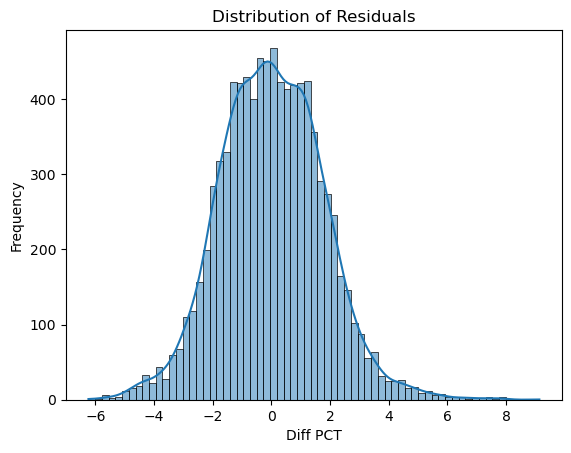

In [161]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [162]:
X_test.shape

(8952, 18)

In [163]:
extreme_error_threshold = 10
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct


In [164]:
extreme_results_df.shape

(0, 4)

In [165]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

0.0

29% extreme error mean the 29% customers were either overcharge or undercharged by 10%.

In [166]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct


472 customers were overcharged or undercharged by more than 50%.

In [167]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed


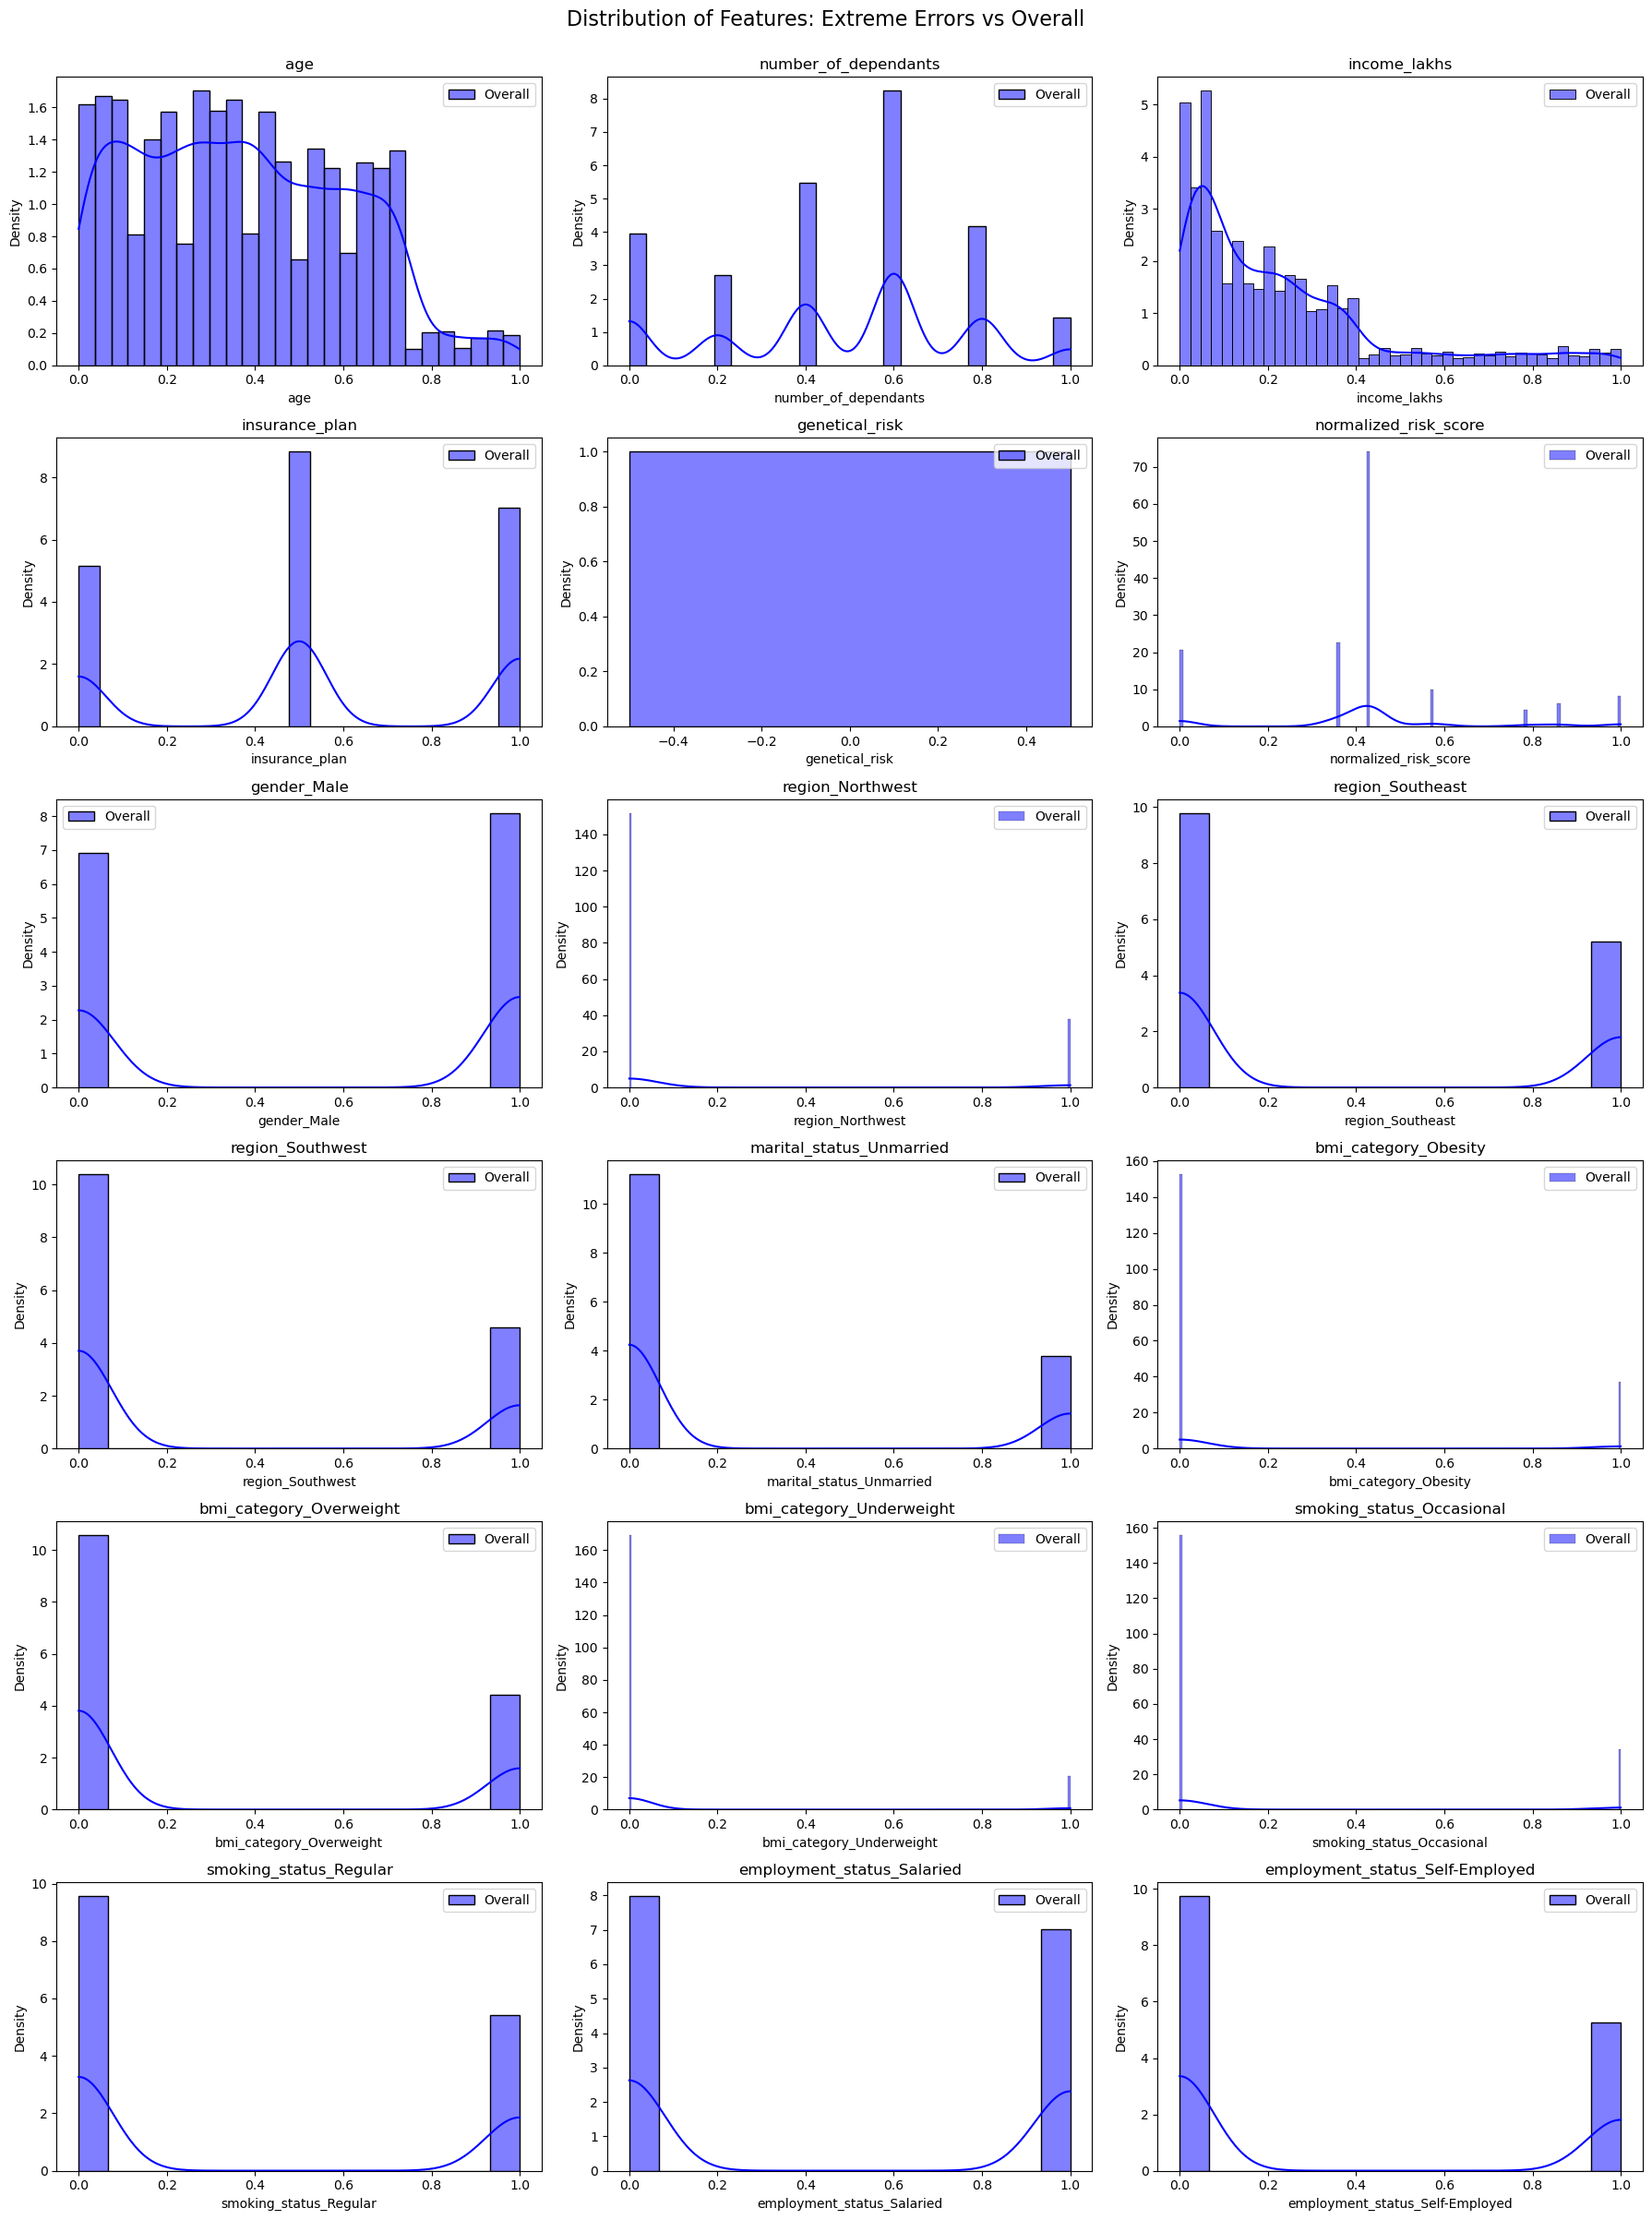

In [168]:
import math
features = X_test.columns
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors',
                 kde=True, stat='density', common_norm=False, ax=ax)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5,
                 kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{feature}')
    ax.legend()

for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle('Distribution of Features: Extreme Errors vs Overall', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

The distribution of extreme error df and age is not same, so there we need to solve the issue

In [171]:
scaler_with_cols

{'scaler': MinMaxScaler(),
 'cols_to_scale': ['age',
  'number_of_dependants',
  'income_level',
  'income_lakhs',
  'insurance_plan',
  'genetical_risk']}

In [172]:
from joblib import dump

dump(best_model_XGR, "artifacts/model_rest.joblib")
scaler_with_cols = {
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(scaler_with_cols, "artifacts/scaler_rest.joblib")

['artifacts/scaler_rest.joblib']